# Loan Default Prediction - Exploratory Data Analysis (EDA)

## Give Me Some Credit (Kaggle Competition)

### Objective

The goal of this notebook is to perform Exploratory Data Analysis (EDA) on the **Give Me Some Credit** dataset to understand the data before building any machine learning models.

This notebook focuses on:

- Understanding dataset structure
- Identifying missing values
- Checking class imbalance
- Studying feature distributions
- Finding relationships between variables
- Performing data quality checks
- Drawing business insights

> **Note:** No preprocessing, feature engineering, balancing, or model training is performed in this notebook. Those tasks will be completed in later notebooks.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_PATH = "../data/cs-training.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape : {df.shape}")

display(df.head())

Dataset Shape : (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
print("Dataset Information")
print("-"*60)

df.info()

print("\n")

display(df.describe().T)

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nColumn Names")

display(pd.DataFrame(df.columns, columns=["Columns"]))

Dataset Information
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0



Duplicate Rows : 0

Column Names


,Columns
0,Unnamed: 0
1,SeriousDlqin2yrs
2,RevolvingUtilizationOfUnsecuredLines
3,age
4,NumberOfTime30-59DaysPastDueNotWorse
5,DebtRatio
6,MonthlyIncome
7,NumberOfOpenCreditLinesAndLoans
8,NumberOfTimes90DaysLate
9,NumberRealEstateLoansOrLines


## Missing Value Analysis

Before building any predictive model, it is important to understand whether the dataset contains missing values.

Missing values can affect model performance and may introduce bias if handled incorrectly.

In this dataset, we will:

- Identify columns with missing values
- Calculate missing percentages
- Visualize missing data
- Decide suitable imputation strategies later (without applying them in this notebook)

In [4]:
missing_count = df.isnull().sum()

missing_percent = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_df = missing_df[missing_df["Missing Count"] > 0]

display(missing_df)

,Missing Count,Missing Percentage
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


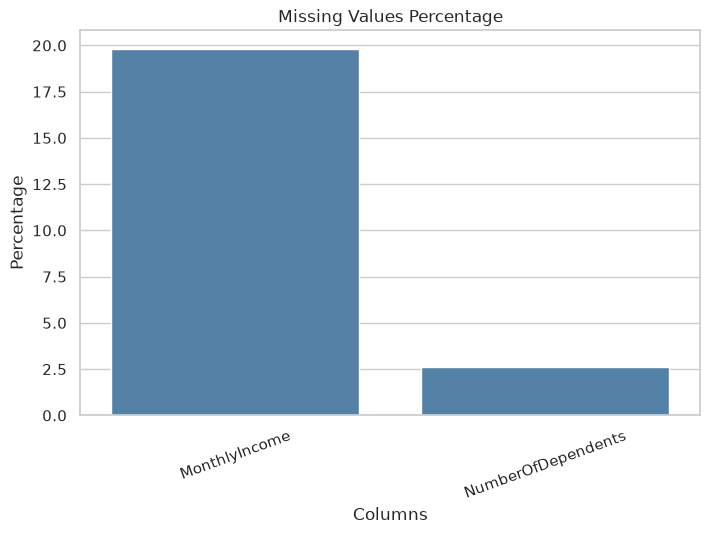

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Missing Percentage"],
    color="steelblue"
)

plt.title("Missing Values Percentage")

plt.ylabel("Percentage")

plt.xlabel("Columns")

plt.xticks(rotation=20)

plt.show()

## Target Variable Analysis

The target column is **SeriousDlqin2yrs**.

- 1 → Borrower experienced serious delinquency within two years.
- 0 → Borrower did not default.

Since this is a loan default prediction problem, class imbalance is expected.

Understanding this imbalance is important because accuracy alone can become misleading.

In [6]:
target = df["SeriousDlqin2yrs"]

counts = target.value_counts()

percent = round(target.value_counts(normalize=True) * 100, 2)

target_df = pd.DataFrame({
    "Count": counts,
    "Percentage": percent
})

display(target_df)

,Count,Percentage
SeriousDlqin2yrs,,
0,139974,93.32
1,10026,6.68


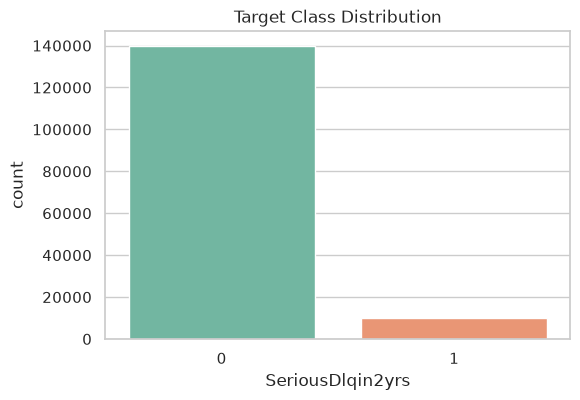

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="SeriousDlqin2yrs",
    data=df,
    palette="Set2"
)

plt.title("Target Class Distribution")

plt.show()

In [8]:
majority_accuracy = (counts.max()/len(df))*100

print(f"Majority Class Accuracy : {majority_accuracy:.2f}%")

print()

print("Observation:")

print("- Dataset is highly imbalanced.")

print("- Predicting every borrower as non-default would already achieve very high accuracy.")

print("- Therefore, Accuracy alone is NOT an appropriate evaluation metric.")

print("- Better metrics include Precision, Recall, F1-score and ROC-AUC.")

Majority Class Accuracy : 93.32%

Observation:
- Dataset is highly imbalanced.
- Predicting every borrower as non-default would already achieve very high accuracy.
- Therefore, Accuracy alone is NOT an appropriate evaluation metric.
- Better metrics include Precision, Recall, F1-score and ROC-AUC.


### Business Interpretation

The dataset is highly imbalanced:

- **93.32%** of borrowers did not default.
- **6.68%** of borrowers experienced serious delinquency within two years.

This means a model that simply predicts every borrower as "non-default" would already achieve **93.32% accuracy**, despite failing to identify high-risk customers.

In real-world banking applications, missing a potential defaulter (False Negative) can result in significant financial losses. Therefore, evaluation metrics such as **ROC-AUC, Precision, Recall, F1-score, Precision-Recall AUC, and KS Statistic** provide a much better assessment of model performance than accuracy alone.

# Univariate Feature Analysis

In this section, each numerical feature is analyzed individually to understand:

- Distribution
- Central tendency
- Spread
- Skewness
- Potential outliers
- Business interpretation

This helps identify data quality issues and guides preprocessing decisions in later stages.

In [10]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("SeriousDlqin2yrs")

print(numeric_columns)

['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


## Statistical Summary of Numerical Features

Before visualizing each feature, we summarize its key statistical properties.

For every numerical feature, we compute:

- Mean
- Median
- Standard Deviation
- Skewness
- Number of Outliers (IQR Method)

This helps identify skewed distributions, extreme values, and features that may require preprocessing in later stages.

In [14]:
summary = []

for column in numeric_columns:

    feature = df[column].dropna()

    q1 = feature.quantile(0.25)
    q3 = feature.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((feature < lower) | (feature > upper)).sum()

    summary.append({
        "Feature": column,
        "Mean": round(feature.mean(), 2),
        "Median": round(feature.median(), 2),
        "Std Dev": round(feature.std(), 2),
        "Minimum": round(feature.min(), 2),
        "Maximum": round(feature.max(), 2),
        "Skewness": round(feature.skew(), 2),
        "Outliers": outliers
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

,Feature,Mean,Median,Std Dev,Minimum,Maximum,Skewness,Outliers
0,RevolvingUtilizationOfUnsecuredLines,6.05,0.15,249.76,0.0,50708.0,97.63,763
1,age,52.30,52.00,14.77,0.0,109.0,0.19,46
2,NumberOfTime30-59DaysPastDueNotWorse,0.42,0.00,4.19,0.0,98.0,22.60,23982
3,DebtRatio,353.01,0.37,2037.82,0.0,329664.0,95.16,31311
4,MonthlyIncome,6670.22,5400.00,14384.67,0.0,3008750.0,114.04,4879
5,NumberOfOpenCreditLinesAndLoans,8.45,8.00,5.15,0.0,58.0,1.22,3980
6,NumberOfTimes90DaysLate,0.27,0.00,4.17,0.0,98.0,23.09,8338
7,NumberRealEstateLoansOrLines,1.02,1.00,1.13,0.0,54.0,3.48,793
8,NumberOfTime60-89DaysPastDueNotWorse,0.24,0.00,4.16,0.0,98.0,23.33,7604
9,NumberOfDependents,0.76,0.00,1.12,0.0,20.0,1.59,13336


### Observations

- Features with large positive skewness may require logarithmic transformation during preprocessing.
- Features containing many outliers should be investigated carefully before model training.
- Extremely skewed financial variables are common in credit-risk datasets because a small number of borrowers have exceptionally high debt or income.
- These observations will guide the preprocessing decisions in the next notebook.

## Correlation Analysis 

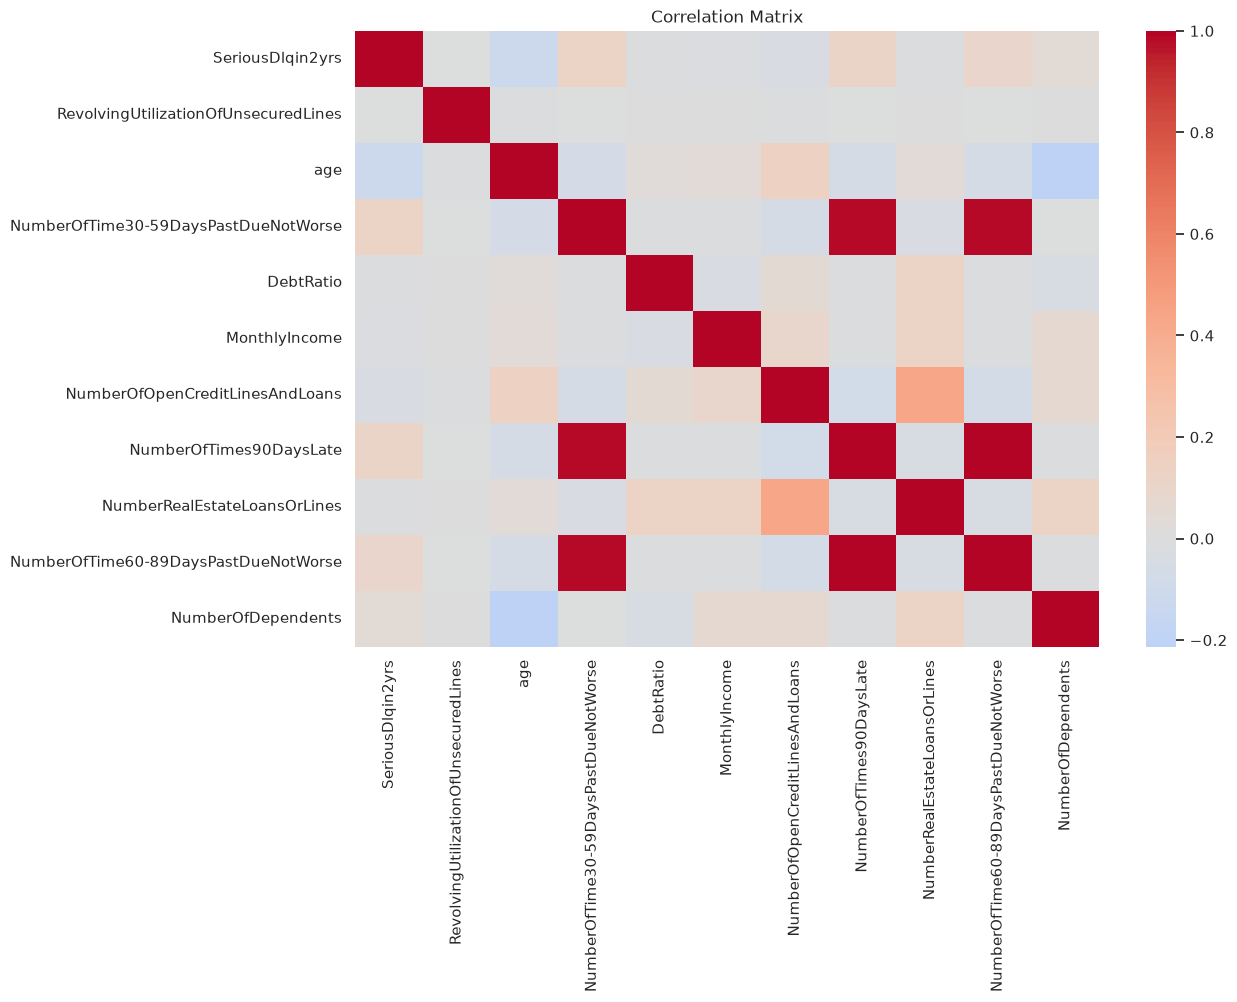

SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

corr["SeriousDlqin2yrs"].sort_values(ascending=False)

### Observations

- Previous delinquency history has the strongest positive relationship with future loan default.
- `NumberOfTime30-59DaysPastDueNotWorse` shows the highest positive correlation (0.126), followed by `NumberOfTimes90DaysLate` (0.117) and `NumberOfTime60-89DaysPastDueNotWorse` (0.102).
- `age` has the strongest negative correlation (-0.115), suggesting older borrowers are generally less likely to default.
- Features such as `MonthlyIncome`, `DebtRatio`, and `NumberOfOpenCreditLinesAndLoans` show relatively weak linear correlations with the target, indicating that nonlinear models like XGBoost may capture their effects better.
- No single feature has an extremely high correlation with the target, suggesting that loan default depends on the combined influence of multiple variables rather than one dominant factor.

In [17]:
print("Age < 18:", (df["age"] < 18).sum())

print("DebtRatio > 10:", (df["DebtRatio"] > 10).sum())

print("RevolvingUtilization > 1:",
      (df["RevolvingUtilizationOfUnsecuredLines"] > 1).sum())

print("90 Days Late == 98:",
      (df["NumberOfTimes90DaysLate"] == 98).sum())

Age < 18: 1
DebtRatio > 10: 28877
RevolvingUtilization > 1: 3321
90 Days Late == 98: 264


### Observations

- One record contains an age below 18, which is likely an invalid entry and should be investigated during preprocessing.
- A large number of borrowers have extremely high `DebtRatio` values (>10), indicating possible outliers or unusual financial situations.
- 3,321 records have `RevolvingUtilizationOfUnsecuredLines` greater than 1 (100%), which may represent over-utilization, reporting anomalies, or special business cases.
- 264 records contain the value 98 for `NumberOfTimes90DaysLate`, which is widely recognized in this dataset as a special coded value rather than an actual delinquency count.
- These unusual values will be handled during the preprocessing stage instead of being modified during exploratory data analysis.